# SciFact and FiQA

Both sets are [BEIR](https://github.com/beir-cellar/beir) collections that RAGBench scores retrieval against. On disk each one has three files:

- `corpus.jsonl` — passages (`_id`, `title`, `text`)
- `queries.jsonl` — questions or claims (`_id`, `text`)
- `qrels/{split}.tsv` — which passages are relevant to which query

RAGBench evaluates the **test** split (`configs/scifact.yaml`, `configs/fiqa.yaml`). The first time FiQA is missing, the next cell downloads it into `data/fiqa`.

In [1]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from ragbench.data.loader import load_dataset

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT.parent / "configs").exists():
    ROOT = ROOT.parent

def word_count(text: str) -> int:
    return len(text.split())

def profile(name: str, split: str = "test"):
    """Load a BEIR dataset the same way the eval runner does."""
    folder = ROOT / "data" / name
    corpus, queries, qrels = load_dataset(name, split=split, local_path=folder)
    gold_per_query = [len(docs) for docs in qrels.values()]
    passage_words = pd.Series([word_count(doc["text"]) for doc in corpus.values()])
    query_words = pd.Series([word_count(text) for text in queries.values()])
    summary = {
        "dataset": name,
        "split": split,
        "passages": len(corpus),
        "passages_with_title": sum(bool(doc["title"].strip()) for doc in corpus.values()),
        "queries_in_file": sum(1 for line in (folder / "queries.jsonl").open() if line.strip()),
        "judged_queries": len(queries),
        "qrel_pairs": sum(gold_per_query),
        "gold_docs_per_query_median": int(pd.Series(gold_per_query).median()),
        "gold_docs_per_query_max": max(gold_per_query),
        "passage_words_median": int(passage_words.median()),
        "query_words_median": int(query_words.median()),
    }
    return corpus, queries, qrels, summary, passage_words, query_words

def preview(corpus, queries, qrels, n=2, words=55):
    """Print a few queries next to a short slice of a relevant passage."""
    shown = 0
    for qid, text in queries.items():
        print(f"Query {qid}: {text}\n")
        for doc_id, score in list(qrels[qid].items())[:1]:
            doc = corpus[doc_id]
            snippet = " ".join(doc["text"].split()[:words])
            title = doc["title"].strip() or "(no title)"
            print(f"  relevant {doc_id} (score {score}) — {title}")
            print(f"  {snippet} ...\n")
        shown += 1
        if shown >= n:
            break

def plot_overview(name, qrels, passage_words, query_words, evidence=None):
    """Bar and histogram views of gold-doc counts, passage length, and query length.

    ``evidence`` is an optional mapping of label -> count (SciFact SUPPORT / CONTRADICT).
    Length axes stop at the 99th percentile so one very long passage does not flatten the chart.
    """
    panels = 4 if evidence else 3
    gold = pd.Series([len(docs) for docs in qrels.values()])
    counts = gold.value_counts().reindex(range(1, int(gold.max()) + 1), fill_value=0)
    # Many distinct gold-counts (FiQA goes to 15) need a horizontal bar so the labels stay readable.
    wide = len(counts) > 8
    fig, axes = plt.subplots(1, panels, figsize=(3.6 * panels, 4.4 if wide else 3.2))

    if wide:
        axes[0].barh(counts.index.astype(int), counts.values, color="#3b6ea5")
        axes[0].set_yticks(counts.index.astype(int))
        axes[0].invert_yaxis()
        axes[0].set_xlabel("Queries")
        axes[0].set_ylabel("Relevant passages")
    else:
        axes[0].bar(counts.index.astype(int), counts.values, color="#3b6ea5")
        axes[0].set_xticks(counts.index.astype(int))
        axes[0].set_xlabel("Relevant passages")
        axes[0].set_ylabel("Queries")
    axes[0].set_title("Gold passages per query")

    def _hist(ax, series, title, color):
        cap = max(int(series.quantile(0.99)), 1)
        # Drop the longest 1% instead of clipping it into the last bin.
        ax.hist(series[series <= cap], bins=30, color=color)
        median = int(series.median())
        ax.axvline(median, color="#c45c26", lw=1.5, label=f"median {median}")
        ax.set_title(title)
        ax.set_xlabel(f"Words (above {cap} omitted)")
        ax.legend(frameon=False, fontsize=8)

    _hist(axes[1], passage_words, "Passage length", "#3b6ea5")
    _hist(axes[2], query_words, "Query length", "#5b8c5a")

    if evidence:
        order = [k for k in ("SUPPORT", "CONTRADICT") if k in evidence]
        order += [k for k in evidence if k not in order]
        colors = {"SUPPORT": "#2f7d4a", "CONTRADICT": "#b54747"}
        axes[3].bar(order, [evidence[k] for k in order], color=[colors.get(k, "#3b6ea5") for k in order])
        axes[3].set_title("Evidence labels")
        axes[3].set_ylabel("Claim–abstract pairs")

    fig.suptitle(name, fontsize=12)
    fig.tight_layout()
    plt.show()

## What `profile` does

`profile` is a helper in the cell above. It is not part of the RAGBench library. It builds a short statistical picture of one dataset on one split.

Given a name such as `"scifact"` or `"fiqa"`, it:

1. Calls `load_dataset`, the same loader the evaluation runner uses. That reads `data/{name}/corpus.jsonl`, `queries.jsonl`, and `qrels/{split}.tsv`. Queries with no judgment on that split are dropped. SciFact's query file has 1,109 lines; the test profile keeps the 300 that appear in `qrels/test.tsv`.
2. Counts passages, how many have a title, how many queries were judged, and how many qrel pairs exist. One pair is one query linked to one relevant passage.
3. Measures how many relevant passages each query has (median and max), and the median word count of passages and of queries.
4. Returns six objects the later cells use: the corpus, the judged queries, the qrels, a summary dict, and two word-count series (one value per passage, one per judged query).

## What a gold document is

A **gold document** is a passage the dataset authors marked as relevant to a query. Those marks live in the qrels file. Retrieval metrics (recall, NDCG, precision) score a pipeline by how high it ranks these passages. Every other passage counts as not relevant for that query.

On SciFact the passages are paper abstracts, so a gold document is a **gold abstract**: the abstract a claim is meant to be checked against. The qrel score is only relevance (`1`). SUPPORT and CONTRADICT are a separate label in the query metadata. They say whether that abstract backs the claim or conflicts with it.

On FiQA a gold document is a forum post judged to answer the question. FiQA has no support/contradict label.

## SciFact

Scientific **claim verification**. A query is a one-sentence claim. A passage is a paper abstract. A relevant abstract is evidence about that claim.

The qrels used for scoring are binary (`score = 1`). Whether the abstract *supports* or *contradicts* the claim is stored separately, in `metadata` on the query.

In [2]:
scifact_corpus, scifact_queries, scifact_qrels, scifact_summary, scifact_passage_words, scifact_query_words = profile("scifact")
display(pd.Series(scifact_summary, name="scifact"))

labels = Counter()
examples = {}
with (ROOT / "data/scifact/queries.jsonl").open() as fh:
    for line in fh:
        row = json.loads(line)
        if str(row["_id"]) not in scifact_qrels:
            continue
        for doc_id, annotations in (row.get("metadata") or {}).items():
            for ann in annotations:
                label = ann.get("label", "UNKNOWN")
                labels[label] += 1
                examples.setdefault(label, (str(row["_id"]), row["text"], str(doc_id)))

print("Evidence labels on the test claims:", dict(labels))
print("Gold abstracts per test claim:")
display(pd.Series([len(docs) for docs in scifact_qrels.values()]).value_counts().sort_index().rename("queries"))
print("Passage length (words):")
display(scifact_passage_words.describe().round(1))

10:09:53 | INFO    | ragbench.data.loader | Loaded 'scifact' [test]: 5183 passages, 300 queries, 300 qrels


dataset                       scifact
split                            test
passages                         5183
passages_with_title              5183
queries_in_file                  1109
judged_queries                    300
qrel_pairs                        339
gold_docs_per_query_median          1
gold_docs_per_query_max             5
passage_words_median              192
query_words_median                 12
Name: scifact, dtype: object

Evidence labels on the test claims: {'SUPPORT': 216, 'CONTRADICT': 122}
Gold abstracts per test claim:


1    277
2     14
3      4
4      3
5      2
Name: queries, dtype: int64

Passage length (words):


count    5183.0
mean      201.8
std        86.0
min        26.0
25%       147.0
50%       192.0
75%       247.0
max      1524.0
dtype: float64

### SciFact in pictures

The first chart counts test claims by how many gold abstracts they have. Most have one. Passage length is the abstract body in words; query length is the claim. The orange line is the median. The longest 1% of texts are left off the length charts so they do not squash the rest of the distribution.

SUPPORT means the abstract backs the claim. CONTRADICT means it conflicts with the claim. The bar counts claim–abstract pairs, so a claim with two cited abstracts contributes twice.

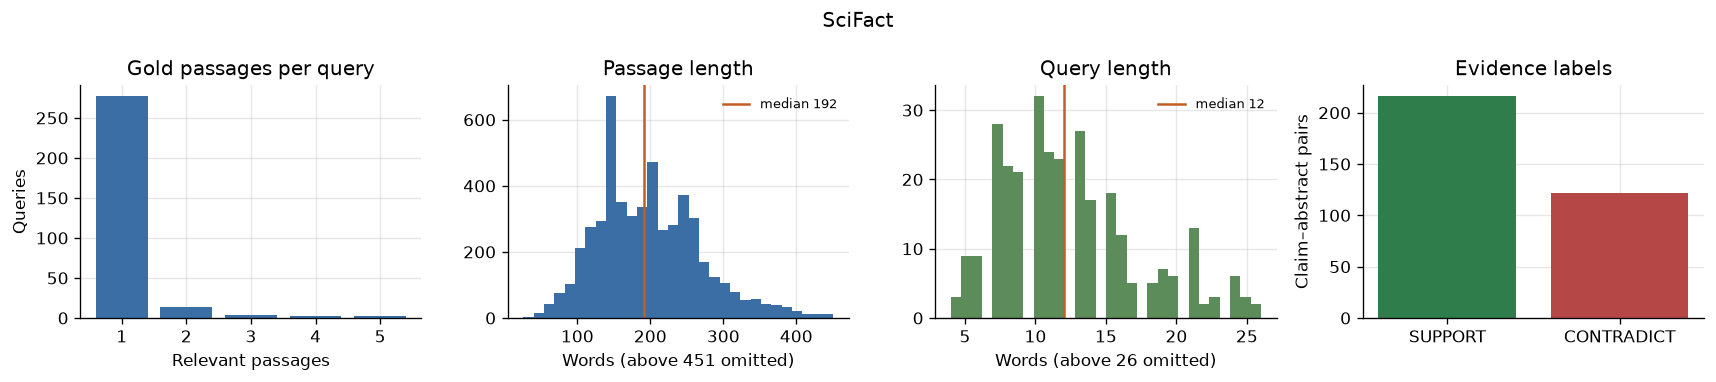

In [3]:
plot_overview(
    "SciFact",
    scifact_qrels,
    scifact_passage_words,
    scifact_query_words,
    evidence=labels,
)

In [4]:
preview(scifact_corpus, scifact_queries, scifact_qrels, n=1)

print("--- one claim of each evidence type ---\n")
for label, (qid, text, doc_id) in examples.items():
    doc = scifact_corpus[doc_id]
    print(f"{label}  query {qid}: {text}")
    print(f"  abstract {doc_id}: {doc['title']}")
    print(f"  {' '.join(doc['text'].split()[:40])} ...\n")

Query 1: 0-dimensional biomaterials show inductive properties.

  relevant 31715818 (score 1) — New opportunities: the use of nanotechnologies to manipulate and track stem cells.
  Nanotechnologies are emerging platforms that could be useful in measuring, understanding, and manipulating stem cells. Examples include magnetic nanoparticles and quantum dots for stem cell labeling and in vivo tracking; nanoparticles, carbon nanotubes, and polyplexes for the intracellular delivery of genes/oligonucleotides and protein/peptides; and engineered nanometer-scale scaffolds for stem cell differentiation and transplantation. This review ...

--- one claim of each evidence type ---

SUPPORT  query 3: 1,000 genomes project enables mapping of genetic sequence variation consisting of rare variants with larger penetrance effects than common variants.
  abstract 14717500: Rare Variants Create Synthetic Genome-Wide Associations
  Genome-wide association studies (GWAS) have now identified at least 2,000 c

## FiQA

Financial **question answering** (FiQA-2018). A query is a user question, often from an investment forum. A passage is an answer-style post. Relevance means the passage addresses the question. There is no support/contradict label.

This is the larger benchmark RAGBench is built around. Expect the download on the first run.

In [5]:
fiqa_corpus, fiqa_queries, fiqa_qrels, fiqa_summary, fiqa_passage_words, fiqa_query_words = profile("fiqa")
display(pd.Series(fiqa_summary, name="fiqa"))
print("Gold passages per test question:")
display(pd.Series([len(docs) for docs in fiqa_qrels.values()]).value_counts().sort_index().rename("queries").head(8))
print("Passage length (words):")
display(fiqa_passage_words.describe().round(1))
preview(fiqa_corpus, fiqa_queries, fiqa_qrels, n=2)

10:09:53 | INFO    | ragbench.data.loader | Loaded 'fiqa' [test]: 57638 passages, 648 queries, 648 qrels


dataset                        fiqa
split                          test
passages                      57638
passages_with_title               0
queries_in_file                6648
judged_queries                  648
qrel_pairs                     1706
gold_docs_per_query_median        2
gold_docs_per_query_max          15
passage_words_median             90
query_words_median               10
Name: fiqa, dtype: object

Gold passages per test question:


1    220
2    184
3    103
4     56
5     29
6     20
7     13
8      8
Name: queries, dtype: int64

Passage length (words):


count    57638.0
mean       132.9
std        128.7
min          0.0
25%         57.0
50%         90.0
75%        159.0
max       2973.0
dtype: float64

Query 4641: Where should I park my rainy-day / emergency fund?

  relevant 44594 (score 1) — (no title)
  "First off, you generally want to park your emergency fund somewhere that is ""safe"", meaning something that is not subject to market fluctuations. Your emergency fund is something you need to be able to count on when times are tough! That rules out things like stock market investments. Secondly, you need to think about how ...

Query 5503: Tax considerations for selling a property below appraised value to family?

  relevant 146277 (score 1) — (no title)
  "Is this legal? Why not? But you might have trouble deducting losses on your taxes, especially if you sell to someone related to you in some way (which is indeed what you're doing). See the added portion below regarding dealing with ""related person"" (which a sibling is). The state of Maryland has a transfer/recordation tax ...



### FiQA in pictures

Same three views as SciFact. A gold passage here is a forum post judged to answer the question, not an abstract, and there is no SUPPORT / CONTRADICT label to plot. The gold-count chart runs further to the right because some questions have many relevant posts.

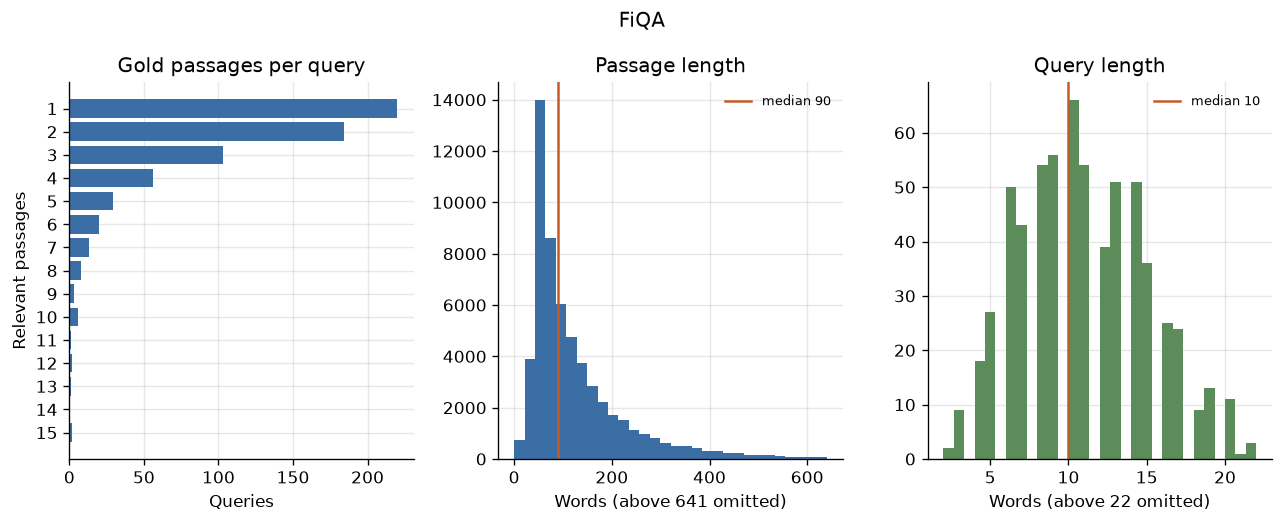

In [6]:
plot_overview("FiQA", fiqa_qrels, fiqa_passage_words, fiqa_query_words)

## Side by side

SciFact is a small, titled, abstract-length corpus of scientific claims, usually with a single gold document. FiQA is a large corpus of untitled forum answers, and a question often has several relevant posts. SciFact is the set to iterate on. FiQA is the set the benchmark is meant to measure.

In [7]:
comparison = pd.DataFrame([scifact_summary, fiqa_summary]).set_index("dataset")
display(comparison.T)

dataset,scifact,fiqa
split,test,test
passages,5183,57638
passages_with_title,5183,0
queries_in_file,1109,6648
judged_queries,300,648
qrel_pairs,339,1706
gold_docs_per_query_median,1,2
gold_docs_per_query_max,5,15
passage_words_median,192,90
query_words_median,12,10


Shares are used below so the two sets can be compared even though FiQA has more queries. Passage length is the share of passages in each word bin. Gold-passage counts are the share of queries with that many relevant passages.

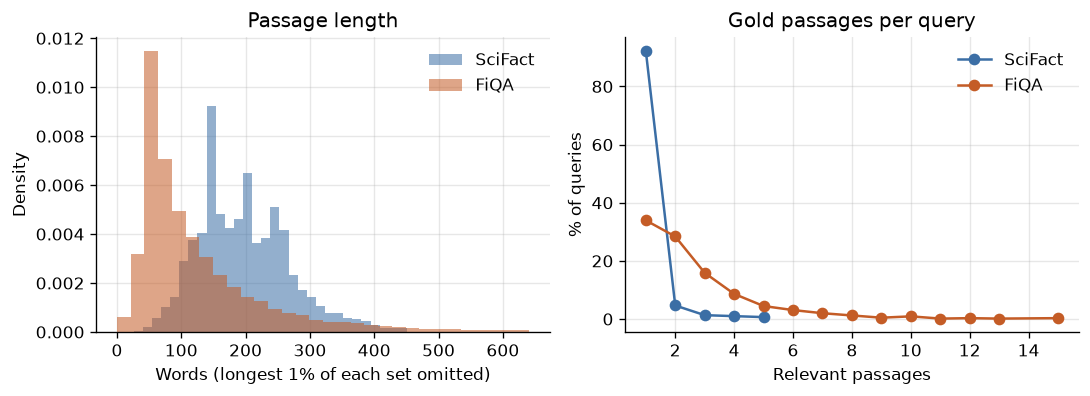

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.4))

for words, label, color in (
    (scifact_passage_words, "SciFact", "#3b6ea5"),
    (fiqa_passage_words, "FiQA", "#c45c26"),
):
    cap = int(words.quantile(0.99))
    axes[0].hist(words[words <= cap], bins=30, density=True, alpha=0.55, label=label, color=color)
axes[0].set_title("Passage length")
axes[0].set_xlabel("Words (longest 1% of each set omitted)")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False)

for qrels, label, color in (
    (scifact_qrels, "SciFact", "#3b6ea5"),
    (fiqa_qrels, "FiQA", "#c45c26"),
):
    gold = pd.Series([len(docs) for docs in qrels.values()])
    share = gold.value_counts(normalize=True).sort_index() * 100
    axes[1].plot(share.index, share.values, marker="o", label=label, color=color)
axes[1].set_title("Gold passages per query")
axes[1].set_xlabel("Relevant passages")
axes[1].set_ylabel("% of queries")
axes[1].legend(frameon=False)

fig.tight_layout()
plt.show()